# Neutron elastic differential cross sections with default Koning-Delaroche (KD03) parameters

This demo computes $d\sigma/d\Omega$ for elastic neutron scattering on $^{40}$Ca, $^{118}$Sn, and $^{208}$Pb at $E_{\rm lab} = 14$ and $50$ MeV, using the default (KD03) parameters of the Koning-Delaroche global optical potential
([Koning & Delaroche, Nucl. Phys. A 713 (2003) 231](https://doi.org/10.1016/S0375-9474(02)01321-0)).

All results are written to a single JSON records file sharing one angular grid.

Workspaces (the expensive, JIT-compiled solver objects) are built once in their own cell;
potential parameters are passed in a separate evaluation cell, so you can tweak the
parameters and re-run only the evaluation without rebuilding anything.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import jitr
from jitr.optical_potentials import kduq

## Set up the potential

`kduq.get_kd03` returns the default KD03 parameter vector (as opposed to
`kduq.get_samples`, which returns the KDUQ posterior samples). The `KDUQ` class
evaluates the corresponding central, spin-orbit, and Coulomb terms for any
parameter vector with this ordering.

In [2]:
neutron = (1, 0)
params_kd03 = kduq.get_kd03(neutron)
omp = kduq.KDUQ(neutron)

dict(zip(kduq.get_param_names(neutron), params_kd03))

{'Ef_0': np.float64(-11.2814),
 'Ef_A': np.float64(0.02646),
 'v1_0': np.float64(59.3),
 'v1_asymm': np.float64(21.0),
 'v1_A': np.float64(0.024),
 'v2_0': np.float64(0.007228),
 'v2_A': np.float64(1.48e-06),
 'v3_0': np.float64(1.994e-05),
 'v3_A': np.float64(2e-08),
 'v4_0': np.float64(7e-09),
 'rv_0': np.float64(1.3039),
 'rv_A': np.float64(0.4054),
 'av_0': np.float64(0.6778),
 'av_A': np.float64(0.0001487),
 'w1_0': np.float64(12.195),
 'w1_A': np.float64(0.0167),
 'w2_0': np.float64(73.55),
 'w2_A': np.float64(0.0795),
 'd1_0': np.float64(16.0),
 'd1_asymm': np.float64(16.0),
 'd2_0': np.float64(0.018),
 'd2_A': np.float64(0.003802),
 'd2_A2': np.float64(8.0),
 'd2_A3': np.float64(156.0),
 'd3_0': np.float64(11.5),
 'rd_0': np.float64(1.3424),
 'rd_A': np.float64(0.01585),
 'ad_0': np.float64(0.5446),
 'ad_A': np.float64(0.0001656),
 'Vso1_0': np.float64(5.922),
 'Vso1_A': np.float64(0.003),
 'Vso2_0': np.float64(0.004),
 'Wso1_0': np.float64(-3.1),
 'Wso2_0': np.float64(160.0),


## Define the systems and the shared angular grid

Angles are center-of-mass frame, in radians on $[0, \pi)$. The same grid is used
for every system and energy so all results can share one grid in the output file.

In [3]:
targets = {
    "40Ca": (40, 20),
    "118Sn": (118, 50),
    "208Pb": (208, 82),
}
energies_MeV = [14.0, 50.0]

angles_cm_deg = np.linspace(0.5, 179.5, 359)
angles = np.deg2rad(angles_cm_deg)

## Build the workspaces

One `DifferentialWorkspace` per (target, energy). The channel radius and
Lagrange-Legendre basis size are chosen per case from the wavenumber, following
the suggested heuristics. This cell also pays the one-time numba JIT compilation
cost via a warmup call, so the evaluation cell below is fast to re-run.

In [4]:
workspaces = {}
for name, target in targets.items():
    for Elab in energies_MeV:
        reaction = jitr.reactions.ElasticReaction(target=target, projectile=neutron)
        kinematics = reaction.kinematics(Elab)

        a = jitr.utils.interaction_range(target[0]) * kinematics.k + 2 * np.pi
        N = jitr.utils.suggested_basis_size(a)
        workspaces[(name, Elab)] = jitr.xs.elastic.DifferentialWorkspace.build_from_system(
            reaction=reaction,
            kinematics=kinematics,
            channel_radius_fm=a / kinematics.k,
            solver=jitr.rmatrix.Solver(N),
            lmax=60,
            angles=angles,
        )

# warmup: trigger numba JIT compilation once
ws = next(iter(workspaces.values()))
_ = ws.xs(central_potential=np.zeros_like(ws.radial_grid()))

list(workspaces)

[('40Ca', 14.0),
 ('40Ca', 50.0),
 ('118Sn', 14.0),
 ('118Sn', 50.0),
 ('208Pb', 14.0),
 ('208Pb', 50.0)]

## Evaluate the potential and compute cross sections

Change `params` here (e.g. to a KDUQ sample, or a hand-modified copy of
`params_kd03`) and re-run just this cell — the workspaces above are reused as-is.

For a neutron there is no Coulomb interaction: the Coulomb term returned by `omp`
is identically zero and `ws.rutherford` is `None`, so we work with the absolute
cross section in mb/sr rather than a ratio to Rutherford.

In [5]:
params = params_kd03

results = {}
for key, ws in workspaces.items():
    central, spin_orbit, coulomb = omp(
        ws.radial_grid(), ws.reaction, ws.kinematics, *params
    )
    results[key] = ws.xs(central, spin_orbit, coulomb)

for (name, Elab), xs in results.items():
    print(
        f"n+{name:>6s} @ {Elab:5.1f} MeV:  "
        f"sigma_tot = {xs.t:8.1f} mb,  sigma_rxn = {xs.rxn:7.1f} mb"
    )

n+  40Ca @  14.0 MeV:  sigma_tot =   2116.9 mb,  sigma_rxn =  1249.7 mb
n+  40Ca @  50.0 MeV:  sigma_tot =   2181.1 mb,  sigma_rxn =   818.7 mb
n+ 118Sn @  14.0 MeV:  sigma_tot =   4590.7 mb,  sigma_rxn =  1969.8 mb
n+ 118Sn @  50.0 MeV:  sigma_tot =   3464.0 mb,  sigma_rxn =  1554.6 mb
n+ 208Pb @  14.0 MeV:  sigma_tot =   5302.5 mb,  sigma_rxn =  2525.8 mb
n+ 208Pb @  50.0 MeV:  sigma_tot =   4344.4 mb,  sigma_rxn =  2260.8 mb


## Plot

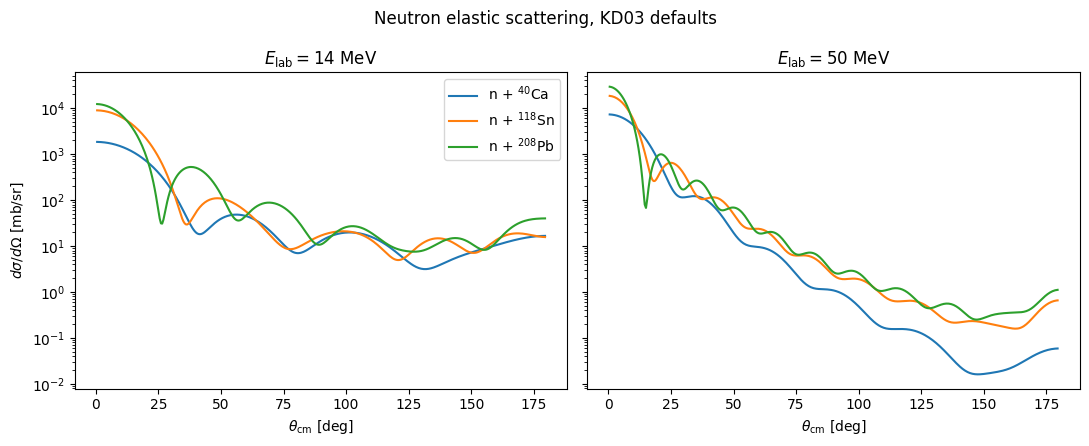

In [6]:
fig, axes = plt.subplots(1, len(energies_MeV), figsize=(11, 4.5), sharey=True)
colors = {name: f"C{i}" for i, name in enumerate(targets)}

for ax, Elab in zip(axes, energies_MeV):
    for name in targets:
        ax.plot(
            angles_cm_deg,
            results[(name, Elab)].dsdo,
            color=colors[name],
            label=rf"n + $^{{{name[:-2]}}}${name[-2:]}",
        )
    ax.set_yscale("log")
    ax.set_xlabel(r"$\theta_{\rm cm}$ [deg]")
    ax.set_title(rf"$E_{{\rm lab}} = {Elab:.0f}$ MeV")

axes[0].set_ylabel(r"$d\sigma/d\Omega$ [mb/sr]")
axes[0].legend()
fig.suptitle("Neutron elastic scattering, KD03 defaults")
fig.tight_layout()

## Write all results to a single JSON records file

The angular grid is stored once at the top level; each record holds the
per-system, per-energy arrays and integrated cross sections.

In [7]:
output = {
    "potential": "Koning-Delaroche KD03 (default parameters)",
    "projectile": "n",
    "angle_cm_deg": angles_cm_deg.tolist(),
    "records": [],
}

for (name, Elab), xs in results.items():
    ws = workspaces[(name, Elab)]
    A, Z = targets[name]
    output["records"].append(
        {
            "target": name,
            "A": A,
            "Z": Z,
            "Elab_MeV": Elab,
            "Ecm_MeV": ws.kinematics.Ecm,
            "k_cm_per_fm": ws.kinematics.k,
            "dsdo_mb_per_sr": xs.dsdo.tolist(),
            "Ay": xs.Ay.tolist(),
            "sigma_total_mb": xs.t,
            "sigma_reaction_mb": xs.rxn,
        }
    )

# we could write to disk like so:
    
# outfile = Path("kd03_neutron_dxs.json")
# outfile.write_text(json.dumps(output, indent=1))
# print(
#     f"wrote {len(output['records'])} records "
#     f"({len(output['angle_cm_deg'])} angles each) to {outfile.resolve()}"
# )

wrote 6 records (359 angles each) to /home/kyle/umich/jitr/examples/notebooks/kd03_neutron_dxs.json
